# ANÁLISIS EXPLORATORIO DE DATOS 💡

El **objetivo** es predecir si un cliente aceptará una tarjeta de crédito o no, utilizando diversas variables demográficas, sociales, financieras y de negocio.


Se sigue una metodología en Ciencia de Datos para asegurar que se realiza una un trabajo riguroso y sistemático que aborda los objetivos del trabajo de manera efectiva

## PROBLEMA

**id**: Identificador único del cliente. Tipo de dato **int64**

**edad**: Edad del cliente. Tipo de dato **int64**

**tipo_trabajo**: Tipo de trabajo del cliente. Tipo de dato **object**

**estado_civil**: 'Estado civil del cliente'. Tipo de dato **object**

**educacion**: Nivel educativo del cliente. Tipo de dato **object**

**mora**: Indicador de morosidad del cliente. Tipo de dato **object**

**vivienda**: Tipo de vivienda del cliente. Tipo de dato **object**

**consumo**: Indicador de uso de TC del cliente . Tipo de dato **object**

**contacto**: Tipo de contacto realizado al cliente. Tipo de dato **object**

**mes**: Mes del último contacto con el cliente. Tipo de dato **object**

**dia**: Día de la semana del último contacto con el cliente. Tipo de dato **object**

**campana**: Estrategias o acciones promocionales de las TC. Tipo de dato **int64**

**dias_ultima_camp**: Días transcurridos desde el último contacto de la campaña anterior. Tipo de dato **int64**

**no_contactos**: Número de contactos realizados antes de la campaña actual. Tipo de dato **int64**

**resultado_anterior**: Resultado del último contacto. Tipo de dato **object**

**emp_var_rate**: Tasa de variación del empleo. Tipo de dato **float64**

**cons_price_idx**: Índice de precios al consumidor. Tipo de dato **float64**

**cons_conf_idx**: Índice de confianza del consumidor. Tipo de dato **float64**

**euribor3m**: Tasa Euribor a 3 meses. Tipo de dato **float64**

**nr_employed**: Indicador económico. Tipo de dato **float64**

**y**: Variable objetivo: Aceptación o no de la tarjeta de crédito. Tipo de dato **int64**

El éxito en la predicción permitirá al Banco focalizar sus esfuerzos en aquellos clientes con mayor probabilidad de aceptar una TC, maximizando su eficiencia y rentabilidad en el proceso de comercialización de tarjetas de crédito.

## RECOPILACIÓN DE DATOS 

Una posible forma de extraer los datos, es por medio de consultas SQL, permitiendo identificar la información demográfica, social, financiera y del propio negocio.

A continuación, se presentan las variables que se utilizarán para llevar a cabo la clasificación:

## COMPRENSIÓN DE DATOS

In [ ]:
#Importación de librerías
import numpy as np  #cálculos numérico
import pandas as pd  #manejo y análisis de datos
import seaborn as sns  #visualización de datos 
import matplotlib.pyplot as plt  #visualización de datos
import scipy.stats #cálculos estadístico
import os

In [ ]:
#Carga datos de entrenamiento (train)
train= pd.read_excel('Data/raw/train.xlsx')
train

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,...,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,57,servicios,casado,bachillerato,NaN,no,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
1,2,37,servicios,casado,bachillerato,no,si,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
2,3,40,administrador negocio,casado,primaria,no,no,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
3,4,56,servicios,casado,bachillerato,no,no,si,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
4,7,25,servicios,single,bachillerato,no,si,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23094,32963,29,desempleado,soltero,preescolar,no,si,no,celular,nov,...,1,9,1,satisfactorio,-1.1,94767,-50.8,1028,4964,0
23095,32964,46,empleado,casado,Estudiante Universitario,no,no,no,celular,nov,...,1,999,0,sin contacto,-1.1,94767,-50.8,1028,4964,0
23096,32965,56,pensionado,casado,pregrado,no,si,no,celular,nov,...,2,999,0,sin contacto,-1.1,94767,-50.8,1028,4964,0
23097,32966,44,tecnico,casado,Estudiante Universitario,no,no,no,celular,nov,...,1,999,0,sin contacto,-1.1,94767,-50.8,1028,4964,1


In [ ]:
#Tamaño de la base de datos
train.shape

(23099, 21)

In [ ]:
#Información general del conjunto de datos
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23099 entries, 0 to 23098
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  23099 non-null  int64  
 1   Edad                23099 non-null  int64  
 2   Tipo_Trabajo        22934 non-null  object 
 3   Estado_Civil        23060 non-null  object 
 4   Educacion           22141 non-null  object 
 5   mora                18333 non-null  object 
 6   Vivienda            22546 non-null  object 
 7   Consumo             22546 non-null  object 
 8   Contacto            23099 non-null  object 
 9   Mes                 23099 non-null  object 
 10  Dia                 23099 non-null  object 
 11  Campana             23099 non-null  int64  
 12  Dias_Ultima_Camp    23099 non-null  int64  
 13  No_Contactos        23099 non-null  int64  
 14  Resultado_Anterior  23099 non-null  object 
 15  emp_var_rate        23099 non-null  float64
 16  cons

### REPORTE

In [ ]:
import sweetviz as sv

/shared-libs/python3.9/py/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
reporte= sv.analyze(train)
reporte.show_html(os.path.join('Data/external', 'reporte.html'))
#reporte.show_notebook()

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)
Report Data/external/reporte.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Duplicados**

In [ ]:
#Valores duplicados
train['ID'].duplicated().any()


False

NO hay clientes duplicados en el conjunto de datos


**Nulos**

In [ ]:
#Valores nulos
train['ID'].isnull().any()

False

El conjunto de datos NO contiene registros de clientes nulos

**Atipícos**

In [ ]:
#Estadísticos descriptivos de las columnas numéricas 
train.drop(["ID", "y"], axis=1).describe(include=[np.number])

,Edad,Campana,Dias_Ultima_Camp,No_Contactos,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,23099.000000,23099.000000,23099.000000,23099.000000,23099.000000,23099.000000,23099.000000,23099.000000,23099.000000
mean,40.067665,2.560154,962.976060,0.171003,0.095649,85576.454652,-40.485237,3190.953288,5167.312611
std,10.449983,2.756954,185.675409,0.494079,1.565650,26224.492288,4.629643,2088.682444,72.186279
min,18.000000,1.000000,0.000000,0.000000,-3.400000,93.000000,-50.800000,1.000000,4964.000000
25%,32.000000,1.000000,999.000000,0.000000,-1.800000,92893.000000,-42.700000,1281.000000,5099.000000
50%,38.000000,2.000000,999.000000,0.000000,1.100000,93876.000000,-41.800000,4856.000000,5191.000000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93994.000000,-36.400000,4961.000000,5228.000000
max,95.000000,42.000000,999.000000,6.000000,1.400000,94767.000000,-26.900000,5045.000000,5228.000000


In [ ]:
#Estadísticos descriptivos de las columnas categóricas
train.describe(include=object)

,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,Dia,Resultado_Anterior
count,22934,23060,22141,18333,22546,22546,23099,23099,23099,23099
unique,11,5,7,2,2,2,2,10,5,3
top,administrador negocio,casado,pregrado,no,si,no,celular,may,thu,sin contacto
freq,5820,13965,6756,18331,12136,19062,14611,7758,4780,19992


**Histogramas**

Ayudan a interpretar la forma de la distribución de los datos: si es simétrica o sesgada, si tiene una o varias modas, si presenta valores atípicos (outliers), etc

Además, permiten identificar patrones y tendencias en el conjunto de datos

#### EMP VAR RATE

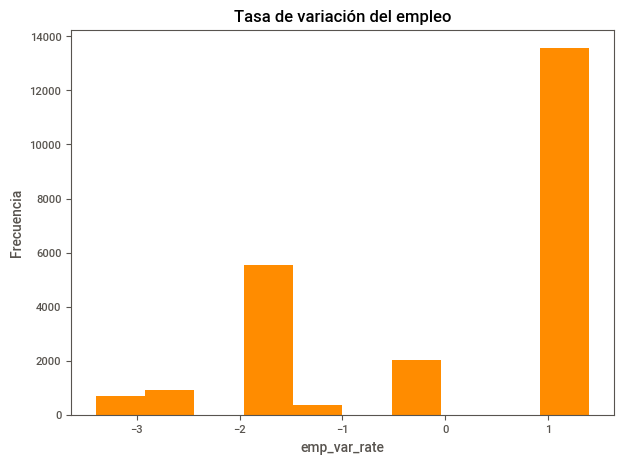

In [ ]:
#Histograma
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(train['emp_var_rate'], bins=10, color='darkorange')
ax.set_title('Tasa de variación del empleo')
ax.set_xlabel('emp_var_rate')
ax.set_ylabel('Frecuencia')
plt.show()

#### CONS PRICE IDX

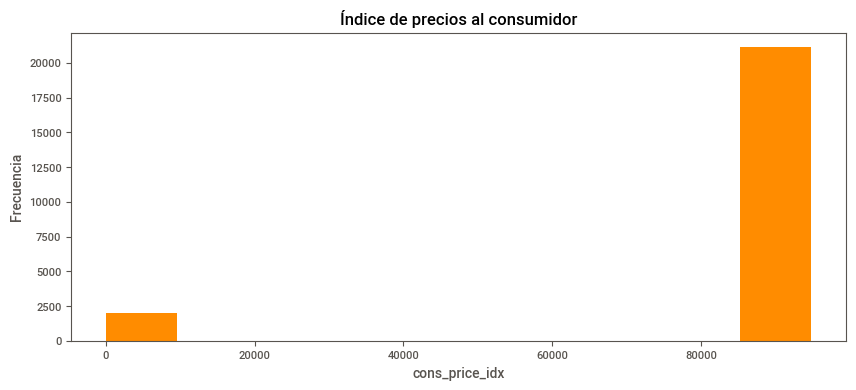

In [ ]:
#Histograma
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train['cons_price_idx'], bins=10, color='darkorange')
ax.set_title('Índice de precios al consumidor')
ax.set_xlabel('cons_price_idx')
ax.set_ylabel('Frecuencia')
plt.show()

#### CONS CONF IDX

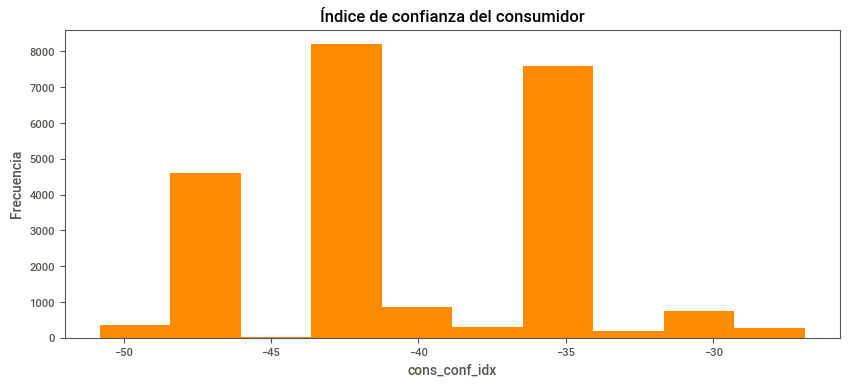

In [ ]:
#Histograma
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train['cons_conf_idx'], bins=10, color='darkorange')
ax.set_title('Índice de confianza del consumidor')
ax.set_xlabel('cons_conf_idx')
ax.set_ylabel('Frecuencia')
plt.show()

#### NR_EMPLOYED

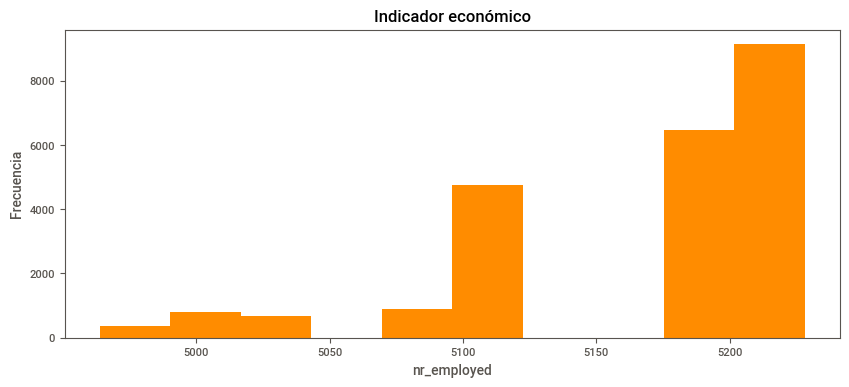

In [ ]:
#Histograma 
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train['nr_employed'], bins=10, color='darkorange')
ax.set_title('Indicador económico')
ax.set_xlabel('nr_employed')
ax.set_ylabel('Frecuencia')
plt.show()

**Gráficos de barras**

Permiten visualizar la frecuencia o proporción de diferentes categorías en un conjunto de datos. 

Ayudan a comparar y analizar las distribuciones de las categorías, identificar las dominantes y detectar posibles variaciones o patrones entre ellas. 

##### EDAD

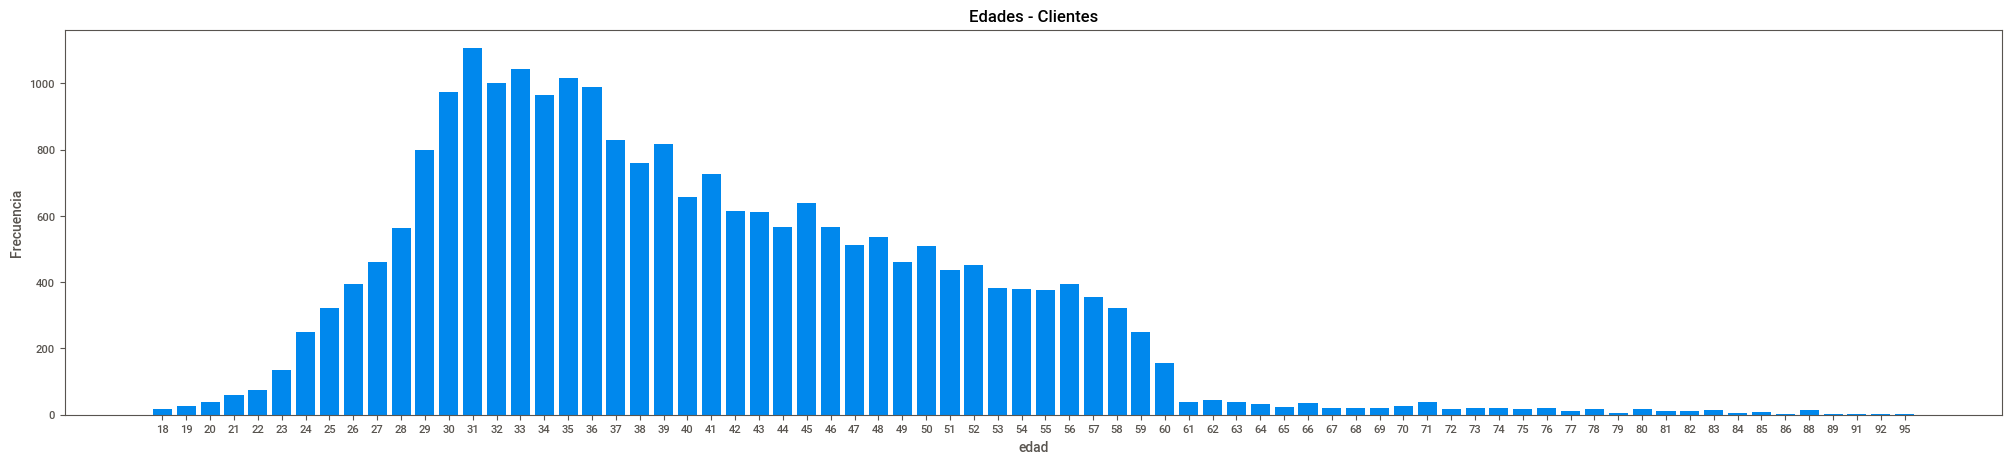

In [ ]:
#Gráfico de barras
fig, ax = plt.subplots(figsize=(25, 5))
counts_edad = train['Edad'].value_counts().sort_index()
ax.bar(counts_edad.index.astype(str), counts_edad.values)
ax.set_title('Edades - Clientes')
ax.set_xlabel('edad')
ax.set_ylabel('Frecuencia')
plt.show()

#### CAMPANA

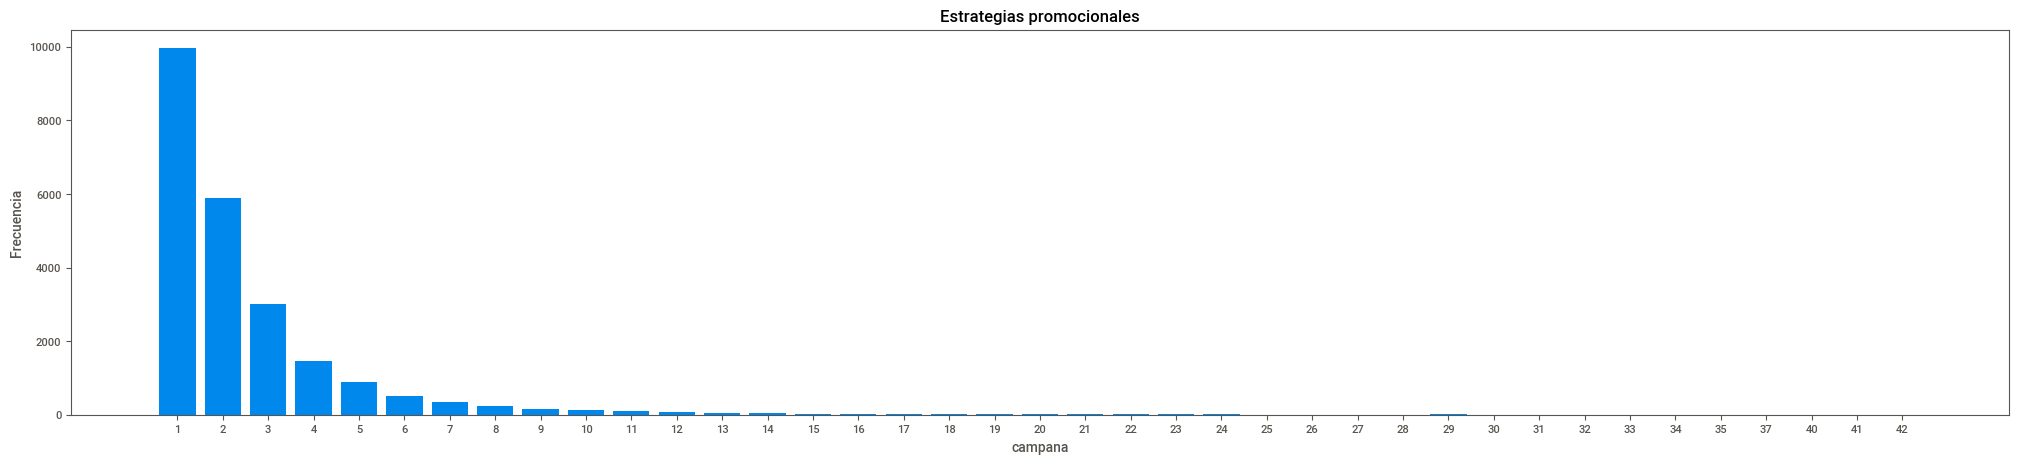

In [ ]:
#Gráfico de barras
fig, ax = plt.subplots(figsize=(25, 5))
counts_campana = train['Campana'].value_counts().sort_index()
ax.bar(counts_campana.index.astype(str), counts_campana.values)
ax.set_title('Estrategias promocionales')
ax.set_xlabel('campana')
ax.set_ylabel('Frecuencia')
plt.show()

#### DIAS ULTIMA CAMP

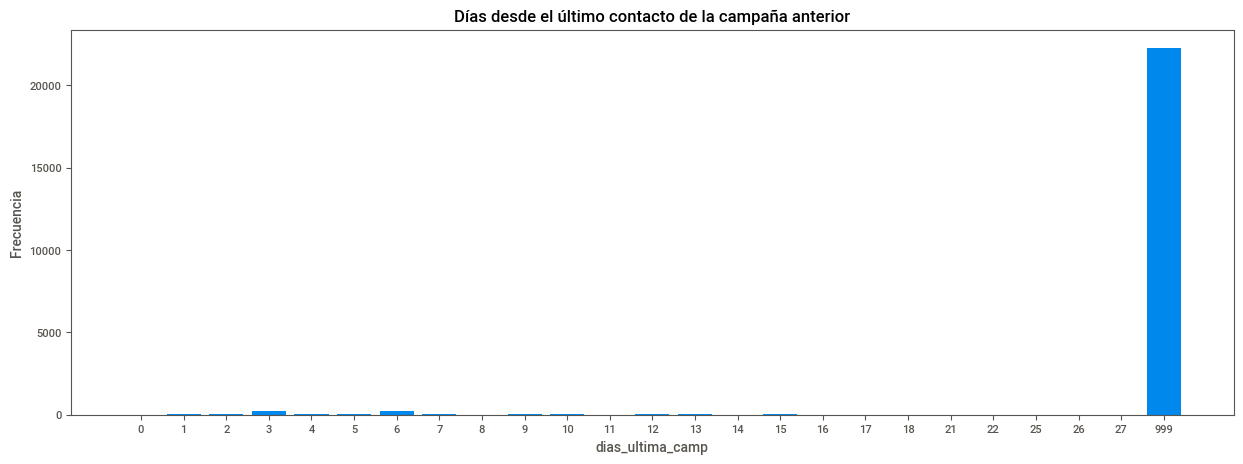

In [ ]:
#Gráfico de barras
fig, ax = plt.subplots(figsize=(15, 5))
counts_dias_ultima_camp = train['Dias_Ultima_Camp'].value_counts().sort_index()
ax.bar(counts_dias_ultima_camp.index.astype(str), counts_dias_ultima_camp.values)
ax.set_title('Días desde el último contacto de la campaña anterior')
ax.set_xlabel('dias_ultima_camp')
ax.set_ylabel('Frecuencia')
plt.show()

#### NO CONTACTOS

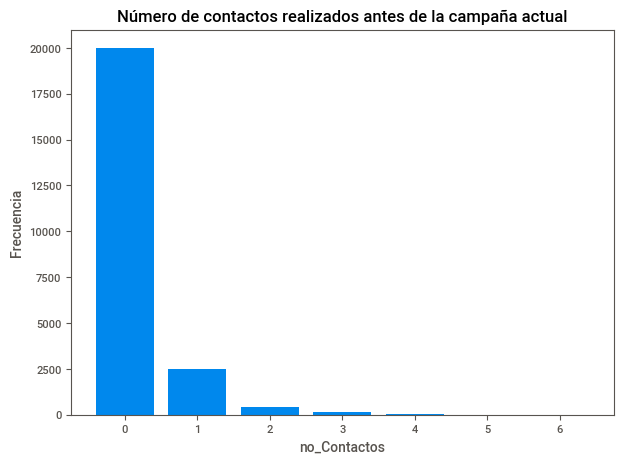

In [ ]:
#Gráfico de barras
fig, ax = plt.subplots(figsize=(7, 5))
counts_no_contactos = train['No_Contactos'].value_counts().sort_index()
ax.bar(counts_no_contactos.index.astype(str), counts_no_contactos.values)
ax.set_title('Número de contactos realizados antes de la campaña actual')
ax.set_xlabel('no_Contactos')
ax.set_ylabel('Frecuencia')
plt.show()

**Gráficos de Densidad**

Probabilidad de que una variable continua tome un valor determinado

#### EURIBOR3M

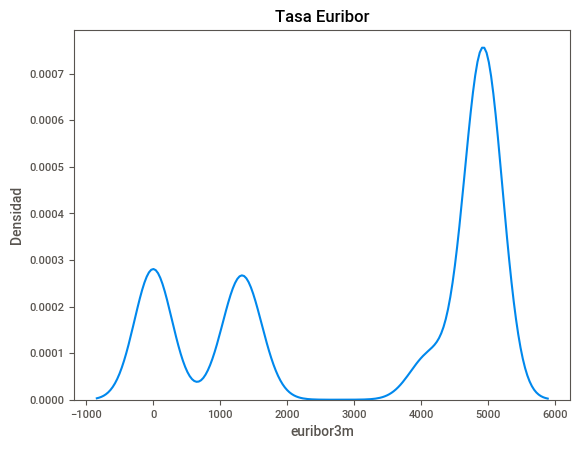

In [ ]:
#Gráfico densidad
sns.kdeplot(train['euribor3m'])
plt.title('Tasa Euribor')
plt.xlabel('euribor3m')
plt.ylabel('Densidad')
plt.show()

##### COE VARIACIÓN
Variabilidad relativa de cada variable en relación con su media

Útil cuando se desea comparar la dispersión de diferentes conjuntos de datos que tienen diferentes unidades de medida o escalas

Evalúa la homogeneidad o heterogeneidad de los datos 
- CV alto indica una mayor dispersión relativa
- CV bajo indica una menor dispersión relativa 

In [ ]:
#Coeficiente variación
coef_variacion= abs(train.std()) / abs(train.mean()) * 100
coef_variacion.sort_values(ascending=False)

emp_var_rate        1636.867606
No_Contactos         288.929672
y                    281.404969
Campana              107.687031
euribor3m             65.456378
ID                    57.984140
cons_price_idx        30.644518
Edad                  26.080839
Dias_Ultima_Camp      19.281415
cons_conf_idx         11.435385
nr_employed            1.396979
dtype: float64

#### INTERACCIÓN ENTRE VARIABLES

##### MATRIZ DE CORRELACIÓN

Relaciones lineales entre pares de variables en un conjunto de datos; utiliza el coeficiente de correlación de Pearson para medir la fuerza y la dirección de la relación lineal entre dos variables

In [ ]:
#Matriz correlacion
matriz_corr= train.drop(["ID"], axis=1).corr()
mascara= np.triu(np.ones_like(matriz_corr, dtype=bool))

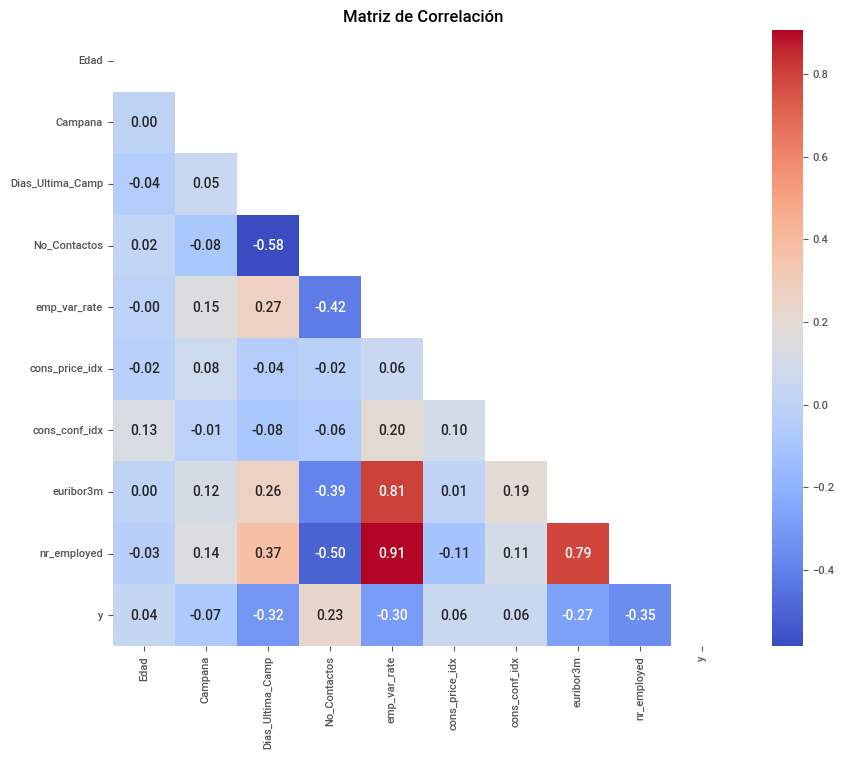

In [ ]:
#Gráfico matriz correlación
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
#Correlación variable objetivo con las variables características 
matriz_corr.loc['y'].sort_values(ascending=False)

y                   1.000000
No_Contactos        0.228306
cons_price_idx      0.056309
cons_conf_idx       0.055895
Edad                0.035514
Campana            -0.068870
euribor3m          -0.271365
emp_var_rate       -0.298051
Dias_Ultima_Camp   -0.319981
nr_employed        -0.354813
Name: y, dtype: float64

##### RELACIONES

In [ ]:
#Meses y dias de los que se tienen registros
meses= ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
dias= ['mon', 'tue', 'wed', 'thu', 'fri']

#Tabla contingencia mes-dia de aceptación
tabla_contingencia= pd.crosstab(index=train['Dia'], columns=train['Mes'], values=train['y'], aggfunc='mean')
tabla_contingencia= tabla_contingencia.reindex(dias, axis=0).reindex(meses, axis=1)

tabla_contingencia


Mes,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
Dia,,,,,,,,,,
mon,0.407895,0.094059,0.076765,0.102564,0.079042,0.081575,0.311111,0.276316,0.089245,0.393939
tue,0.597222,0.321678,0.057522,0.131931,0.075740,0.103878,0.549296,0.444444,0.123077,0.642857
wed,0.609756,0.301775,0.060292,0.119485,0.094089,0.134286,0.507692,0.475610,0.092975,0.526316
thu,0.500000,0.276888,0.066809,0.098881,0.079702,0.100930,0.524590,0.445652,0.104167,0.434783
fri,0.528302,0.103245,0.069544,0.084485,0.111876,0.111675,0.380282,0.500000,0.101990,0.384615


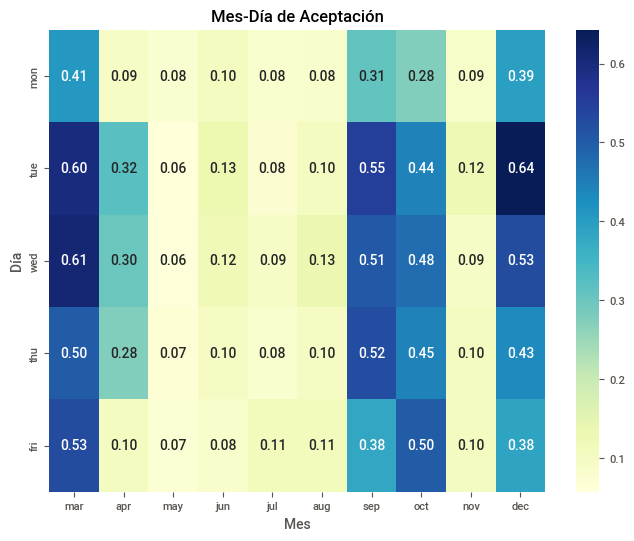

In [ ]:
#Mapa de calor mes-dia de aceptación
plt.figure(figsize=(8, 6))
sns.heatmap(tabla_contingencia, cmap='YlGnBu', annot=True, fmt=".2f", cbar=True)
plt.xlabel('Mes')
plt.ylabel('Día')
plt.title('Mes-Día de Aceptación')
plt.show()

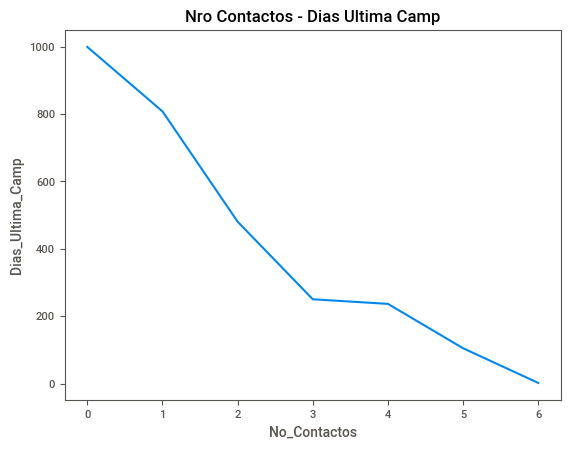

In [ ]:
#Gráfico linea
sns.lineplot(data=train, x='No_Contactos', y='Dias_Ultima_Camp', errorbar=None)
plt.title('Nro Contactos - Dias Ultima Camp')
plt.show()


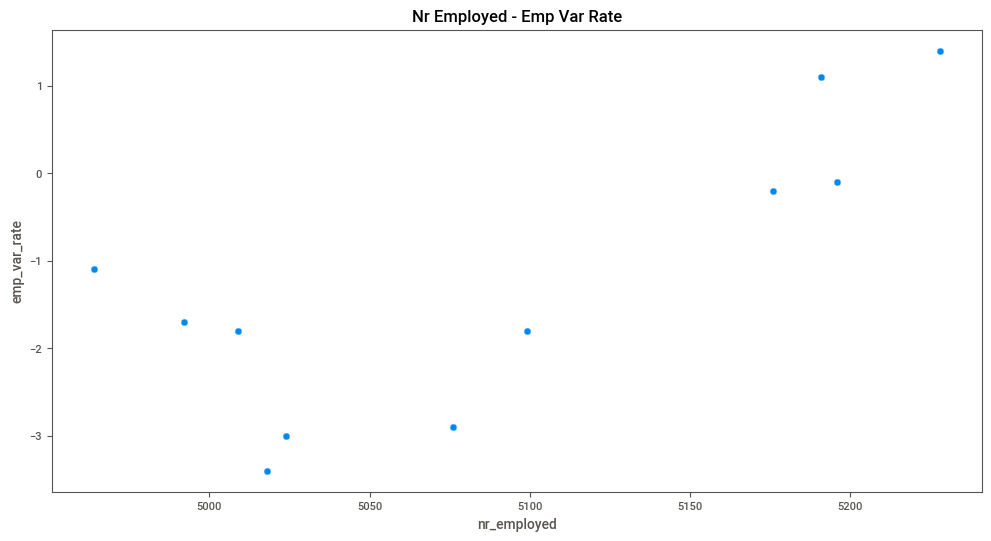

In [ ]:
#Gráfico de dispersión
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='nr_employed', y='emp_var_rate', alpha=1/2, s=25)
plt.title('Nr Employed - Emp Var Rate')
plt.show()

<Figure size 1200x600 with 0 Axes>

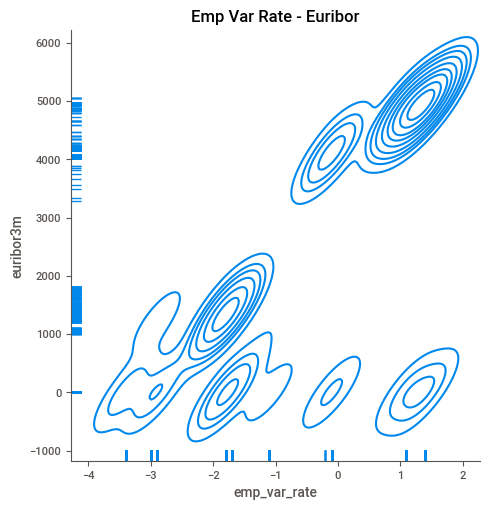

In [ ]:
#Kernel Density Estimation
plt.figure(figsize=(12, 6))
sns.displot(data=train, x='emp_var_rate', y='euribor3m', rug=True, kind='kde')
plt.title('Emp Var Rate - Euribor')
plt.show()

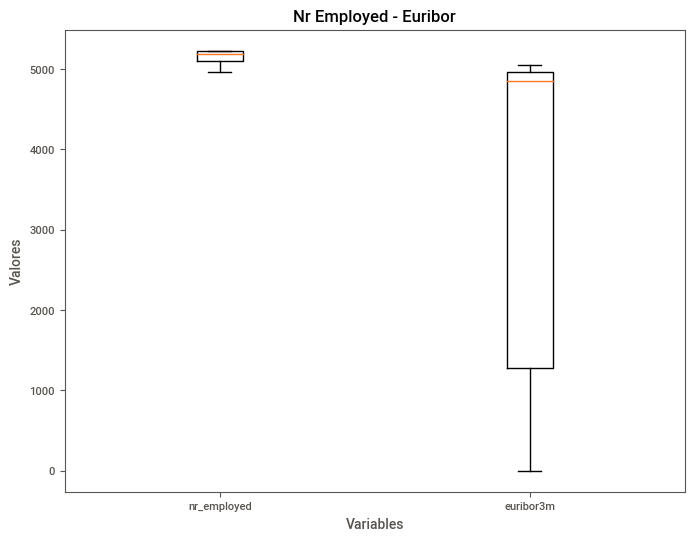

In [ ]:
#BoxPlot
nr_employed= train['nr_employed']
euribor3m= train['euribor3m']
plt.figure(figsize=(8,6))
plt.boxplot([nr_employed, euribor3m], labels=['nr_employed', 'euribor3m'])
plt.xlabel('Variables')
plt.ylabel('Valores')
plt.title('Nr Employed - Euribor')
plt.show()

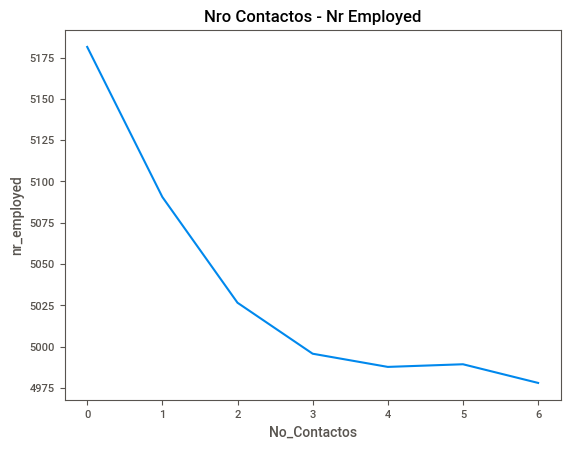

In [ ]:
#Gráfico de linea
sns.lineplot(data=train, x='No_Contactos', y='nr_employed', errorbar=None)
plt.title('Nro Contactos - Nr Employed')
plt.show()

##### PROBABILIDADES

**No_Contactos**

Proporción de clientes que tuvieron algún tipo de contacto y aceptaron la tarjeta entre aquellos que la aceptaron independientemente de si hubo un contacto previo

Es útil para comprender si al establecer una nueva comunicación con un cliente, este estaría dispuesto a aceptar la tarjeta

In [ ]:
total_contactados= len(train[(train['No_Contactos']>0) & (train['y']==1)])
total_aceptados= len(train[train['y']==1])
probabilidad_aceptacion= round(total_contactados/total_aceptados,2)
probabilidad_aceptacion

0.32

**euribor3m**

Probabilidad de aceptación de tarjetas de crédito para diferentes niveles de la tasa Euribor

In [ ]:
quartiles= train['euribor3m'].quantile([0, 0.33, 0.66, 1])
limites= list(quartiles.values)
etiquetas= ['BAJO', 'MEDIO', 'ALTO']
train['grupo_euribor3m']= pd.cut(train['euribor3m'], bins=limites, labels=etiquetas, right=False)

In [ ]:
euribor_bajo= train.loc[train['grupo_euribor3m']=='BAJO', 'euribor3m']
euribor_medio= train.loc[train['grupo_euribor3m']=='MEDIO', 'euribor3m']
euribor_alto= train.loc[train['grupo_euribor3m']=='ALTO', 'euribor3m']

Proporción de clientes que aceptaron la tarjeta de credito en un momento en el que la tasa euribor tenia un valor 'BAJO' entre aquellos que la aceptaron independiente del valor al que rigiera la tasa en ese momento

Es útil para..

In [ ]:
total_euribor_bajo= len(train.loc[(train['grupo_euribor3m']=='BAJO') & (train['y'] == 1), 'euribor3m'])
total_aceptados = len(train[train['y']==1])
probabilidad_aceptacion= round(total_euribor_bajo / total_aceptados,2)
probabilidad_aceptacion

0.62

Proporción de clientes que aceptaron la tarjeta de credito en un momento en el que la tasa euribor tenia un valor 'MEDIO' entre aquellos que la aceptaron independiente del valor al que rigiera la tasa en ese momento

Es útil para..

In [ ]:
total_euribor_medio= len(train.loc[(train['grupo_euribor3m']=='MEDIO') & (train['y']==1), 'euribor3m'])
total_aceptados= len(train[train['y']==1])
probabilidad_aceptacion= round(total_euribor_medio / total_aceptados,2)
probabilidad_aceptacion

0.21

Proporción de clientes que aceptaron la tarjeta de credito en un momento en el que la tasa euribor tenia un valor 'ALTO' entre aquellos que la aceptaron independiente del valor al que rigiera la tasa en ese momento

Es útil para..

In [ ]:
total_euribor_alto= len(train.loc[(train['grupo_euribor3m']=='ALTO') & (train['y']==1), 'euribor3m'])
total_aceptados= len(train[train['y']==1])
probabilidad_aceptacion= round(total_euribor_alto / total_aceptados,2)
probabilidad_aceptacion

0.17

**emp_var_rate**

Probabilidad de aceptación de tarjetas de crédito para diferentes niveles de la tasa de variación del empleo

In [ ]:
quartiles= train['emp_var_rate'].quantile([0, 0.5, 1])
limites= list(quartiles.values)
etiquetas= ['BAJO', 'ALTO']
train['grupo_emp_var_rate']= pd.cut(train['emp_var_rate'], bins=limites, labels=etiquetas, right=True, duplicates='drop', include_lowest=True)

In [ ]:
emp_var_rate_bajo= train.loc[train['grupo_emp_var_rate']=='BAJO', 'emp_var_rate']
emp_var_rate_alto= train.loc[train['grupo_emp_var_rate']=='ALTO', 'emp_var_rate']

Proporción de clientes que aceptaron la tarjeta de credito en un momento en el que la tasa del empleo tenia un valor 'BAJO' entre aquellos que la aceptaron independiente del valor al que rigiera la tasa en ese momento

Es útil para..

In [ ]:
total_emp_var_rate_bajo= len(train.loc[(train['grupo_emp_var_rate']=='BAJO') & (train['y']==1), 'emp_var_rate'])
total_aceptados = len(train[train['y']==1])
probabilidad_aceptacion= round(total_emp_var_rate_bajo / total_aceptados,2)
probabilidad_aceptacion

0.81

In [ ]:
min(emp_var_rate_bajo)

-3.4

In [ ]:
max(emp_var_rate_bajo)

1.1

Proporción de clientes que aceptaron la tarjeta de credito en un momento en el que la tasa del empleo tenia un valor 'ALTO' entre aquellos que la aceptaron independiente del valor al que rigiera la tasa en ese momento

Es útil para..

In [ ]:
total_emp_var_rate_alto= len(train.loc[(train['grupo_emp_var_rate']=='ALTO') & (train['y']==1), 'emp_var_rate'])
total_aceptados = len(train[train['y']==1])
probabilidad_aceptacion= round(total_emp_var_rate_alto / total_aceptados,2)
probabilidad_aceptacion

0.19

In [ ]:
min(emp_var_rate_alto)

1.4

In [ ]:
max(emp_var_rate_alto)

1.4

**Dias_Ultima_Camp**

Probabilidad de aceptación de los clientes dado los días transcurridos desde el último contacto de la campaña anterior

In [ ]:
aceptados= train[train['y'] == 1]
rechazados= train[train['y'] == 0]

In [ ]:
prob_aceptacion= aceptados.groupby('Dias_Ultima_Camp').size()/len(aceptados)
prob_rechazo= rechazados.groupby('Dias_Ultima_Camp').size()/len(rechazados)

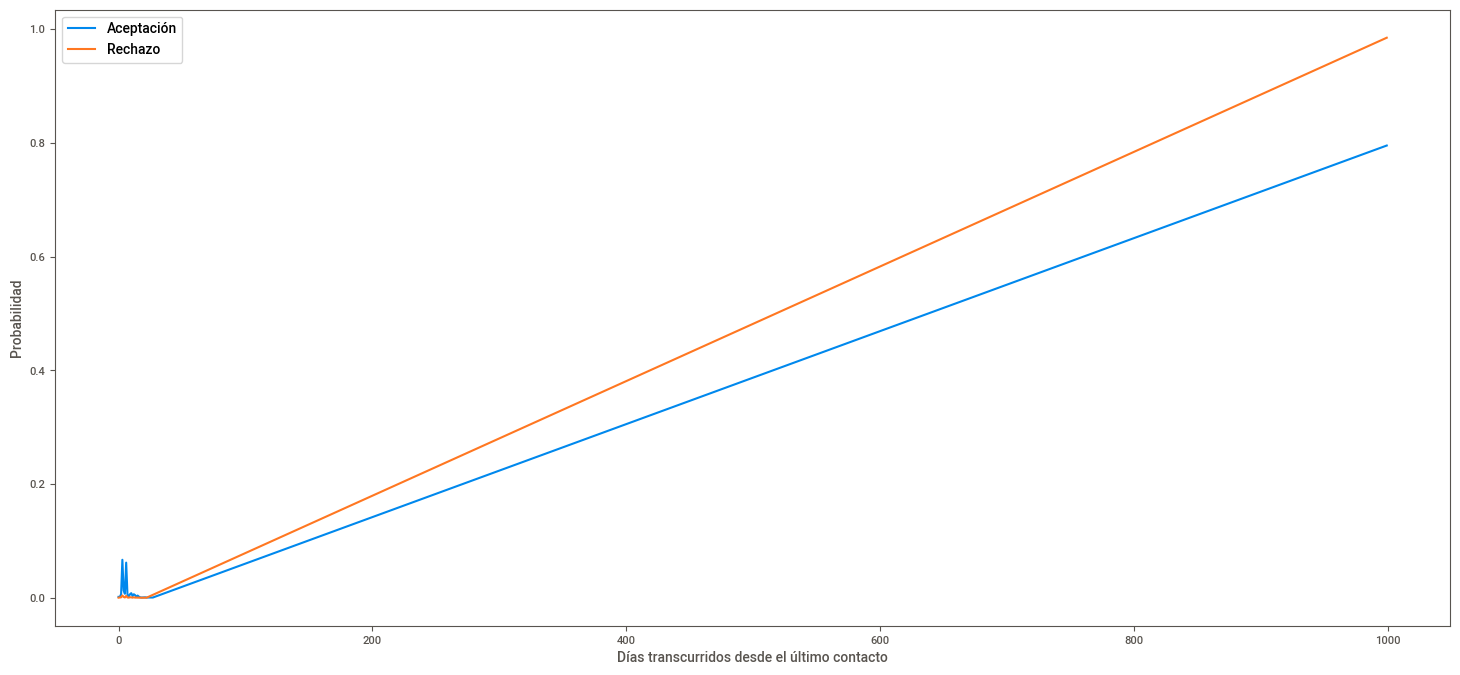

In [ ]:
plt.figure(figsize=(18,8))
plt.plot(prob_aceptacion.index, prob_aceptacion.values, label='Aceptación')
plt.plot(prob_rechazo.index, prob_rechazo.values, label='Rechazo')
plt.xlabel('Días transcurridos desde el último contacto')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()

In [ ]:
train[train['Dias_Ultima_Camp'] >= 30]['Dias_Ultima_Camp'].count()

22261

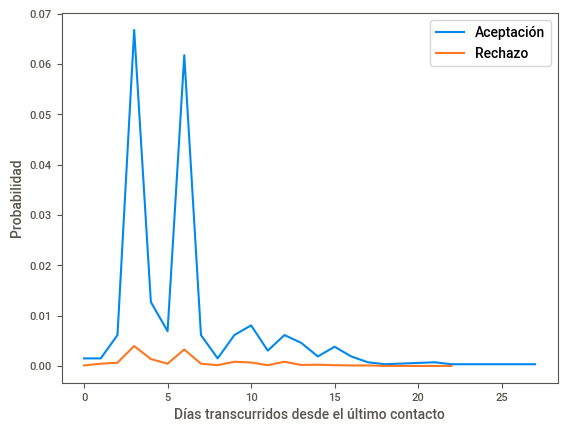

In [ ]:
#Filtrar 30 primeros días
prob_aceptacion_primeros_30= prob_aceptacion[prob_aceptacion.index <= 30]
prob_rechazo_primeros_30= prob_rechazo[prob_rechazo.index <= 30] 

#Gráfico con los datos filtrados
plt.plot(prob_aceptacion_primeros_30.index, prob_aceptacion_primeros_30.values, label='Aceptación')
plt.plot(prob_rechazo_primeros_30.index, prob_rechazo_primeros_30.values, label='Rechazo')
plt.xlabel('Días transcurridos desde el último contacto')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()

In [ ]:
train[train['Dias_Ultima_Camp'] <= 30]['Dias_Ultima_Camp'].count()

838

**nr_employed**

Probabilidad de aceptación de tarjetas de crédito para diferentes niveles del indicador económico

In [ ]:
quartiles= train['nr_employed'].quantile([0, 0.5, 1])
limites= list(quartiles.values)
etiquetas= ['BAJO', 'ALTO']
train['grupo_nr_employed']= pd.cut(train['nr_employed'], bins=limites, labels=etiquetas, right=True, duplicates='drop', include_lowest=True)

In [ ]:
nr_employed_bajo= train.loc[train['grupo_nr_employed']=='BAJO', 'nr_employed']
nr_employed_alto= train.loc[train['grupo_nr_employed']=='ALTO', 'nr_employed']

Proporción de clientes que aceptaron la tarjeta de credito en un momento en el que la tasa del empleo tenia un valor 'BAJO' entre aquellos que la aceptaron independiente del valor al que rigiera la tasa en ese momento

Es útil para..

In [ ]:
total_nr_employed_bajo= len(train.loc[(train['grupo_nr_employed']=='BAJO') & (train['y']==1), 'nr_employed'])
total_aceptados = len(train[train['y']==1])
probabilidad_aceptacion= round(total_nr_employed_bajo / total_aceptados,2)
probabilidad_aceptacion

0.77

In [ ]:
min(nr_employed_bajo)

4964

In [ ]:
max(nr_employed_bajo)

5191

Proporción de clientes que aceptaron la tarjeta de credito en un momento en el que el indicador económico tenia un valor 'ALTO' entre aquellos que la aceptaron independiente del valor al que rigiera la tasa en ese momento

Es útil para..

In [ ]:
total_nr_employed_alto= len(train.loc[(train['grupo_nr_employed']=='ALTO') & (train['y']==1), 'nr_employed'])
total_aceptados = len(train[train['y']==1])
probabilidad_aceptacion= round(total_nr_employed_alto / total_aceptados,2)
probabilidad_aceptacion

0.23

In [ ]:
min(nr_employed_alto)

5196

In [ ]:
max(nr_employed_alto)

5228

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ed4e5f13-3af9-48d3-90dc-acc295659d32' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>